## Avalanches in the Computational Model

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit
import numpy as np
import os

In [8]:
import os
#m = np.load('fir_thalamus_maxtor2_soglia_4.npy', allow_pickle =True)

In [5]:
cd D:

D:\


In [6]:
cd new_data_thalamus/

D:\new_data_thalamus


In [9]:
import sys
import warnings
warnings.filterwarnings("ignore")

In [19]:
path ="C:/Users/Benedetta/Desktop/Criticality in barrel cortex/Codes/Marianietal2026-PlosCompBio"

In [30]:
sys.path.append(path + '\Modules')
from avalanches_functions import *
from functions import * 
from plotting_functions import *
import matplotlib
matplotlib.rc('font', **{'family':'serif', 'serif': ['Computer Modern']})
matplotlib.rc('text', usetex=True)

In [ ]:
ls

In [32]:
cd "C:/Users/Benedetta/Downloads/Barrel+Talamo/Barrel+Talamo"

C:\Users\Benedetta\Downloads\Barrel+Talamo\Barrel+Talamo


In [34]:
cd new_data_thalamus/

D:\new_data_thalamus


In [31]:
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 25

In [35]:
import os
import numpy as np
import scipy.signal as ss
import mat73

thalamus = True
start = 0
if not thalamus:
    rat = 4
    
    file = os.listdir()[1:][rat]
    data_dict = mat73.loadmat(file)
    data = data_dict['amplifier_data']
    stim = data_dict['adc_data']
    indexes = (np.where(stim> 1.5)[0])[np.where(np.diff(np.where(stim> 1.5)[0])>1)]
    
    indexes = np.array(indexes.tolist() + [int(indexes[-1] + np.diff(indexes)[-1])]) - 125
    fs = 25000
    

if thalamus:
    rat = 0
    file = os.listdir()[start:][rat]
    data_dict = mat73.loadmat(file)
    data = data_dict['amplifier_data']
    stim = data_dict['adc_data'][0]
    indexes = (np.where(stim> 1.5)[0])[np.where(np.diff(np.where(stim> 1.5)[0])>1)]
    indexes = np.array(indexes.tolist() + [int(indexes[-1] + np.diff(indexes)[-1])]) - 125
    fs = 25000


In [36]:
import os
import numpy as np
import scipy.signal as ss
import scipy.signal as ss
fs = 25000
nTrials = 28
nchan = 30
nchan_c = 27
import scipy.signal as ss
##spikes

fs = 25000
nyq = 0.5*fs
T =10

low = 300/nyq
high = 3000/nyq
b,a = ss.butter(2,[low,high], "bandpass")
spikes = ss.filtfilt(b,a,data,axis = 1, padlen=150)
spikes = (spikes - np.mean(spikes,0)) # substracting mean population trend (artifact removal)

spikesTrials = []
if not thalamus:
    for r in range(1,nTrials+1):
        spikesTrials.append(spikes[:nchan_c,indexes[r]-int(fs):indexes[r]+ int(fs*T)])
    spikesTrials = np.array(spikesTrials)
else:
    spikes = (spikes[:nchan])
    for r in range(1,nTrials+1):
        spikesTrials.append(spikes[:,indexes[r]-int(fs):indexes[r]+int(fs*T)])
    spikesTrials = np.array(spikesTrials)


In [37]:
spikesTrials.shape[2]/25000

11.0

In [38]:
nch = spikesTrials.shape[1]
num = spikesTrials.shape[0]
binspikes =  np.zeros((num,nch,spikesTrials.shape[2]), dtype = int)
soglia = 3
for r in range(num):
    for ch in range(nch):
        binspikes[r,ch,:] = findpeaks(spikesTrials[r,ch,:],Thres(soglia,spikesTrials[r,ch,:]),"neg", dist=10)


In [39]:
def compute_fr_v(data, mean_interspike_time, coef):
    ev = data
    #ev = np.sum(data, axis=1).astype(int)
    T = int(mean_interspike_time * coef)

    cumsum = np.cumsum(np.insert(ev, 0, 0))
    density = (cumsum[T:] - cumsum[:-T]) / T

    # padding finale per mantenere stessa lunghezza
    density = np.concatenate([density, np.zeros(T-1)])

    return density

In [42]:
binspikes.shape

(28, 30, 275000)

In [40]:
def compute_fr_v(data, mean_interspike_time, coef):
    ev = data
    #ev = np.sum(data, axis=1).astype(int)
    T = int(mean_interspike_time * coef)

    cumsum = np.cumsum(np.insert(ev, 0, 0))
    density = (cumsum[T:] - cumsum[:-T]) / T

    # padding finale per mantenere stessa lunghezza
    density = np.concatenate([density, np.zeros(T-1)])

    return density
total_f = np.zeros(binspikes.shape)

for g in range(nTrials):
    for n in range(nch):
        f= compute_fr_v(binspikes[g,n,:], 500,3)
        #plt.plot(f)
        total_f[g,n] = f

In [43]:
total_f.shape

(28, 30, 275000)

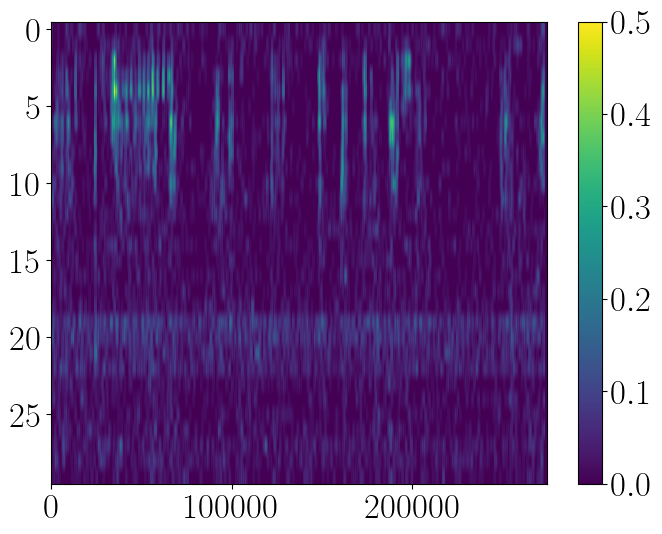

In [44]:
plt.figure(figsize=(8,6))
trial =4
plt.imshow(total_f[trial,::-1,]*25, aspect='auto')#,extent= [0,25000*10,0,30,], vmax=0.2, cmap='Reds');
plt.colorbar()
#plt.xticks(np.arange(0,25000*11,25000),labels = (np.arange(0,25000*11,25000)/25000-1).astype(int));

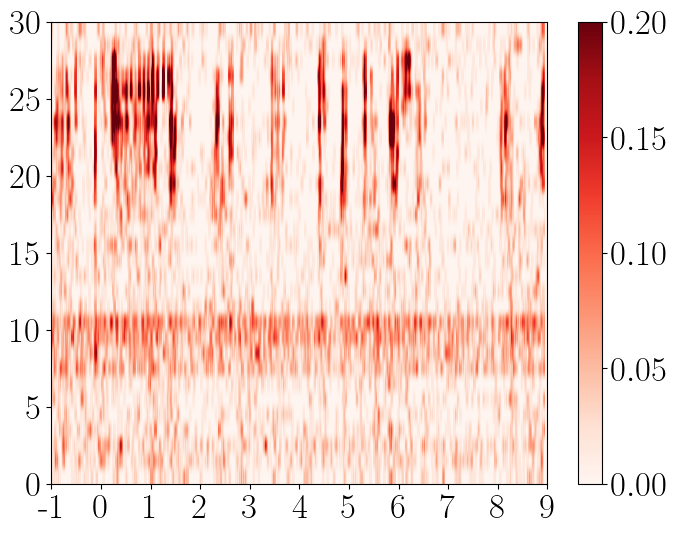

In [45]:
plt.figure(figsize=(8,6))
trial =4
plt.imshow(total_f[trial,::-1,]*25, aspect='auto',extent= [0,25000*10,0,30,], vmax=0.2, cmap='Reds');
plt.colorbar()
plt.xticks(np.arange(0,25000*11,25000),labels = (np.arange(0,25000*11,25000)/25000-1).astype(int));

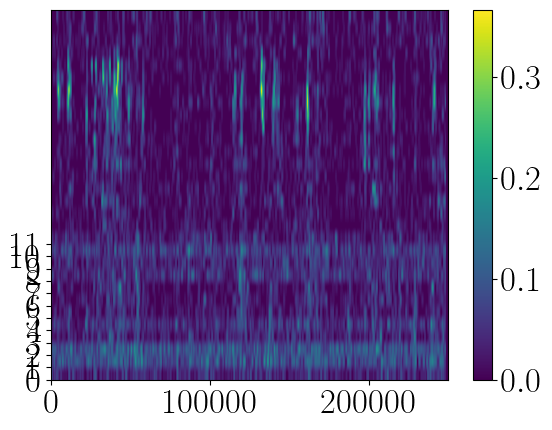

In [113]:
plt.imshow(total_f[2,::-1,]*25, aspect='auto',extent= [0,25000*10,0,30,]);
plt.colorbar()
plt.yticks(np.arange(0,12,1));

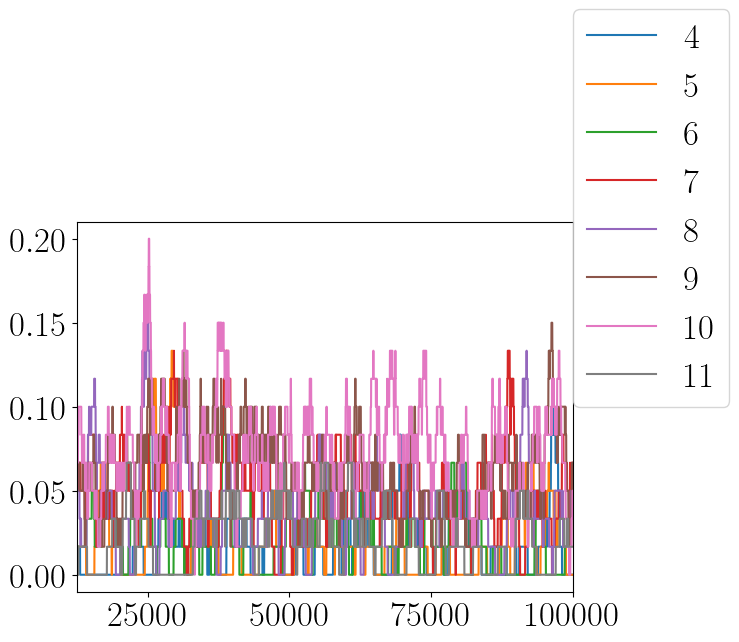

In [46]:

trial=10
plt.plot(total_f[trial,4,:]*25, label='4',)
plt.plot(total_f[trial,5,:]*25,label='5')
plt.plot(total_f[trial,6,:]*25,label='6')
plt.plot(total_f[trial,7,:]*25,label='7')


plt.plot(total_f[trial,8,:]*25,label='8')
plt.plot(total_f[trial,9,:]*25,label='9')
plt.plot(total_f[trial,10,:]*25,label='10')
plt.plot(total_f[trial,11,:]*25,label='11');
plt.xlim(0,25000*2);
plt.legend(loc=(1,0.5));
plt.xlim(25000-12500,25000+25000*3);


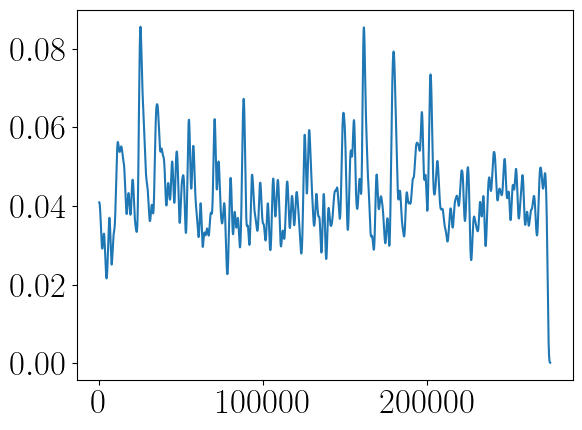

In [47]:
from scipy.ndimage import gaussian_filter1d
plt.plot(gaussian_filter1d(np.mean(total_f[0,6:12,:],0),500)*25);
#plt.plot(gaussian_filter1d(fir[0,25000:,10],500)*25, color='red');
#plt.xlim(0,25000*10)

In [23]:
total_f.shape

(28, 30, 275000)

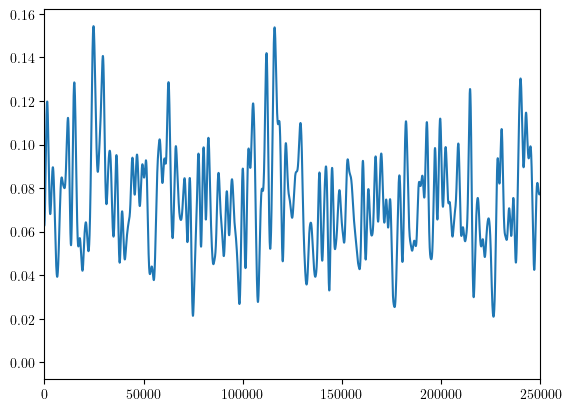

In [40]:
from scipy.ndimage import gaussian_filter1d
plt.plot(gaussian_filter1d(total_f[15,10],500)*25);
#plt.plot(gaussian_filter1d(fir[0,25000:,10],500)*25, color='red');
plt.xlim(0,25000*10);

In [ ]:
m.shape

In [48]:
from numba import njit
plt.rcParams;
plt.rcParams['text.usetex'] =True
plt.rcParams['font.family'] = 'serif',
plt.rcParams['font.serif'] =  'Computer Modern'

In [34]:
plt.rcParams['font.size'] = 25

In [32]:
#ls D:

In [39]:
fir = total_f

In [36]:
path_figures = 'C:/Users/Benedetta/Desktop/Criticality in barrel cortex/Thalamus/Paper figures'
path = 'C:/Users/Benedetta/Desktop/Criticality in barrel cortex/numpy files'

In [ ]:
#path = '../../../Desktop/Criticality in barrel cortex/numpy files'

In [10]:
import os
os.listdir(path);

In [11]:
fir = np.load(os.path.join(path,'fir_thalamus_soglia_4.npy'))

In [7]:
fi

(28, 275000, 30)

In [49]:
from scipy.special import erf

def ModelOscillWilsonBook(t_final,dt,x_0,proc):

    def Acti(V,theta, rho, Tx):
        return (1 + erf((V -(theta - rho))/Tx))/2
    
    ec = 42
    ic = 12
    tce = 12
    tci = 10
    taue = 5
    taui = 15
    
    wee = 1
    wei = 1
    
    wie = 2
    wii = 1.5
    
    wte = 3.9
    wti = 1.5### original 6
    gamma_e = 5
    gamma_i = 15
    
    er = 2.2##original 7.4
    ir = 4.1
    
    Te = 12.03
    Ti = 11.62
    rho = -60
    theta = -45
    
    
    S0 =np.random.random(2)*x_0
    
    T = t_final
    N = int(T/dt)
  
    S = np.zeros((2,N))
    P = np.zeros(N)
    S[:,0] = S0
    for r in range(N-1):
        P[r] = gamma_e*(1-er*Acti(S[0,r],theta,rho,Te))*Acti(wee*ec*S[0,r]+ wte*tce*(proc[r])-wie*ic*S[1,r],theta,rho,Te)
        S[0,r+1] = S[0,r] +(-S[0,r] + P[r])*dt/taue
        S[1,r+1] = S[1,r] +(-S[1,r] + gamma_i*(1-ir*Acti(S[1,r],theta,rho,Ti))*Acti(wei*ec*S[0,r]+ wti*tci*(proc[r])-wii*ic*S[1,r],theta,rho,Ti))*dt/taui
    P[-1] = gamma_e*(1-er*Acti(S[0,-1],theta,rho,Te))*Acti(wee*ec*S[0,-1]+ wte*tce*(proc[-1])-wie*ic*S[1,-1],theta,rho,Te)
    #P[-1] = 
    return S, P

In [32]:
#ls D:

In [4]:
path_figures = 'C:/Users/Benedetta/Desktop/Criticality in barrel cortex/Thalamus/Paper figures'
path = 'C:/Users/Benedetta/Desktop/Criticality in barrel cortex/numpy files'

In [26]:
path_comp = "C:/Users/Benedetta/Desktop/Criticality in barrel cortex/Codes/Marianietal2026-PlosCompBio/Modules"
import sys
sys.path.append(path_comp)

from avalanches_functions import *
from functions import *
from plotting_functions import *
from power import * 
from powerlaw_fit import *
from stats import *

In [27]:
import powerlaw as pwl
import numpy as np
#from powerlaw_fit import *
#from stats import *
#from power import *
from matplotlib import cm
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import MultipleLocator
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from matplotlib.path import Path
from matplotlib import patches
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerLineCollection
import pandas as pd
#from numba import njit
from statsmodels.regression import linear_model as sm

matplotlib.rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
matplotlib.rc('text', usetex=True)

In [49]:
path_figures

'C:/Users/Benedetta/Desktop/Criticality in barrel cortex/Thalamus/Paper figures'

(275000, 6)
10.999960000000002
11.0


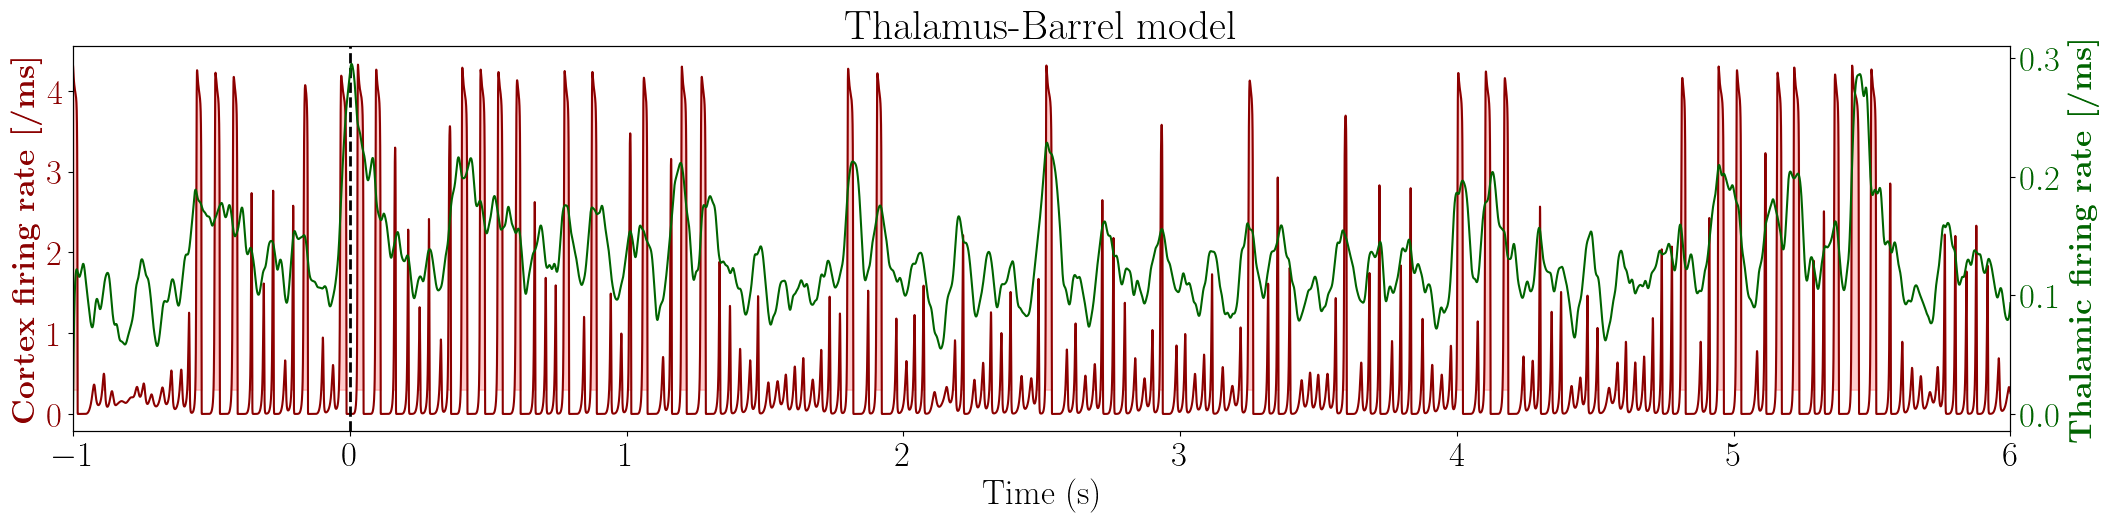

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
trial = 0
fir = total_f[:,6:12,:25000*11]
#rint(fir.shape)
fir = fir.transpose(0,2,1)
print(fir[trial].shape)
mean_ch = np.mean(fir[trial], 1)*25
#mean_ch = np.mean(fir[trial,:,6:12], 1)
T = 1000*11
sample_rate = 25000
taue = 5
dt = 0.04
N = int(T/dt)
times = np.arange(0,T,0.04)
times = times*1e-3
#print(S_rest.shape[0]/25000)
# sigma in campioni
sigma_samples = 100 # ad esempio 5 campioni
smoothed = gaussian_filter1d(mean_ch, sigma=sigma_samples)

psth = smoothed/np.max(smoothed)*0.3#*25*7
proc = np.zeros(N)

for g in range(N-1):
    proc[g+1] = proc[g] +(-proc[g]*dt + psth[g]*dt)/taue

print(times[-1])
S = ModelOscillWilsonBook(T,dt,2,proc)
ii = 35

proc_rest = proc
S_rest = S[1]

def detect_avalanches(firing_rate, threshold):
    """
    Calcola le valanghe in una traccia di firing rate.
    Restituisce anche gli intervalli start-end di ciascuna valanga.
    """
    above_thresh = firing_rate > threshold
    avalanche_sizes = []
    avalanche_intervals = []
    avalanche_dur = []
    in_avalanche = False
    start_idx = 0
    o=0

    for i, active in enumerate(above_thresh):
        if active and not in_avalanche:
            # Inizio valanga
            in_avalanche = True
            start_idx = i
        elif not active and in_avalanche:
            # Fine valanga
            in_avalanche = False
            end_idx = i
            area = np.sum(firing_rate[start_idx:end_idx] - threshold)
            avalanche_sizes.append(area)
            avalanche_intervals.append((start_idx, end_idx))
            avalanche_dur.append(end_idx-start_idx)

    # Gestione ultima valanga
    if in_avalanche:
        area = np.sum(firing_rate[start_idx:] - threshold)
        avalanche_sizes.append(area)
        avalanche_intervals.append((start_idx, len(firing_rate)))
        avalanche_dur.append(len(firing_rate)-start_idx)
        
    #above=(S_rest >0.01).astype(int)
    start = np.where(np.diff(above_thresh.astype(int))>0)
    end= np.where(np.diff(above_thresh.astype(int))<0)
    #print(o)
    return avalanche_sizes, avalanche_intervals, avalanche_dur, start, end

threshold=0.3
print(S_rest.shape[0]/25000)
avalanches, intervals,dur, s,e= detect_avalanches(S_rest, threshold)
T = 1000*11
sample_rate = 25000
taue = 5
dt = 0.04
N = int(T/dt)
times = np.arange(0,T,0.04) 
times = times*1e-3-1
# --- Plot ---
fig, ax = plt.subplots(1,1,figsize=(25,5))
ax.plot(times, S_rest, color='darkred')
#p = moving_window(S_rest,int(25000*0.1),func= np.mean)

#ax.plot(times, p[:len(times)], color='orange',lw=2, )

ax.tick_params(axis='y', labelcolor='darkred')

ax.axvline(0, color='black', linestyle='--', lw=2)
ax.set_ylabel(r"\textbf{Cortex firing rate [/ms]}", fontsize = 23, color ='darkred')
# Evidenzia valanghe
for start, end in intervals:
    ax.fill_between(times[start:end], threshold, S_rest[start:end],
                     color='red', alpha=0.2)
ax1 = ax.twinx()
ax1.plot(times, proc_rest, color='darkgreen')
ax1.tick_params(axis='y', labelcolor='darkgreen')
#ax.plot(
ax.set_xlabel("Time (s)")
ax1.set_ylabel(r"\textbf{Thalamic firing rate [/ms]}", fontsize = 23,color='darkgreen')
plt.title("Thalamus-Barrel model")
plt.xlim(-1,6);

#ax.legend()
#plt.show()
## leggermi articolo di shew...
plt.savefig(path_figures+ '/' + 'Model_poster.jpg', dpi=300, bbox_inches='tight');

In [56]:
total_f.shape

(28, 30, 275000)

In [81]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
S_trial =[]
proc_trial =[]
for trial in range(28):
    
    fir = total_f[:,6:12,:25000*11]
    #rint(fir.shape)
    fir = fir.transpose(0,2,1)
    print(fir[trial].shape)
    mean_ch = np.mean(fir[trial], 1)*25
    #mean_ch = np.mean(fir[trial,:,6:12], 1)
    T = 1000*11
    sample_rate = 25000
    taue = 5
    dt = 0.04
    N = int(T/dt)
    times = np.arange(0,T,0.04)
    times = times*1e-3
    #print(S_rest.shape[0]/25000)
    # sigma in campioni
    sigma_samples = 100 # ad esempio 5 campioni
    smoothed = gaussian_filter1d(mean_ch, sigma=sigma_samples)
    
    psth = smoothed/np.max(smoothed)*0.3#*25*7
    proc = np.zeros(N)
    
    for g in range(N-1):
        proc[g+1] = proc[g] +(-proc[g]*dt + psth[g]*dt)/taue
    
    print(times[-1])
    S = ModelOscillWilsonBook(T,dt,2,proc)
    ii = 35
    
    proc_rest = proc
    S_rest = S[1]
    
    
    threshold=0.3
    print(S_rest.shape[0]/25000)
    avalanches, intervals,dur, s,e= detect_avalanches(S_rest, threshold)
    T = 1000*11
    sample_rate = 25000
    taue = 5
    dt = 0.04
    N = int(T/dt)
    times = np.arange(0,T,0.04) 
    times = times*1e-3-1
    S_trial.append(S_rest)
    proc_trial.append(proc_rest)

(275000, 6)
10.999960000000002
11.0
(275000, 6)
10.999960000000002
11.0
(275000, 6)
10.999960000000002
11.0
(275000, 6)
10.999960000000002
11.0
(275000, 6)
10.999960000000002
11.0
(275000, 6)
10.999960000000002
11.0
(275000, 6)
10.999960000000002
11.0
(275000, 6)
10.999960000000002
11.0
(275000, 6)
10.999960000000002
11.0
(275000, 6)
10.999960000000002
11.0
(275000, 6)
10.999960000000002
11.0
(275000, 6)
10.999960000000002
11.0
(275000, 6)
10.999960000000002
11.0
(275000, 6)
10.999960000000002
11.0
(275000, 6)
10.999960000000002
11.0
(275000, 6)
10.999960000000002
11.0
(275000, 6)
10.999960000000002
11.0
(275000, 6)
10.999960000000002
11.0
(275000, 6)
10.999960000000002
11.0
(275000, 6)
10.999960000000002
11.0
(275000, 6)
10.999960000000002
11.0
(275000, 6)
10.999960000000002
11.0
(275000, 6)
10.999960000000002
11.0
(275000, 6)
10.999960000000002
11.0
(275000, 6)
10.999960000000002
11.0
(275000, 6)
10.999960000000002
11.0
(275000, 6)
10.999960000000002
11.0
(275000, 6)
10.9999600000000

In [53]:
pwd

'D:\\new_data_thalamus'

In [57]:
S_trial = np.asarray(S_trial)
ev_trial = []
for vect in S_trial:
    ev = poisson_thinning_vectorized(vect,0.04,30)
    ev_trial.append(ev)


In [58]:
del spikes, spikesTrials, data

In [60]:
ev_trial = np.asarray(ev_trial)
ev_trial.shape[2]/25000

11.0

In [61]:
concat = concatenat_spikes(ev_trial,3,11,28,fs = 25000)

In [64]:
concat.shape

(5800000, 30)

In [63]:
ev = np.zeros((20,25000*11))
N = ev.shape[1]
dt = 0.04
for g in range(ev.shape[0]):
    spikes2 = np.zeros((N,))
    rnumbers = np.random.random(N)
    prob = S_rest*dt
    spikes2[rnumbers<prob] = 1

    ev[g,:] = spikes2


In [106]:
275000*0.04

11000.0

In [56]:
def poisson_thinning(F, T,N_neurons):
    # F = rate array in Hz, uniform dt
    dt = 0.04
    #T / len(F)
    dt_sec = dt
    lambda_max = np.max(F)
    spikes = []

    for n in range(N_neurons):
        t = 0.0
        neuron_spikes = []
        while t < T:  # convert ms -> s
            # inter-event time from max rate Poisson
            dt_event = np.random.exponential(1/lambda_max)
            t += dt_event
            # accept spike with thinning
            idx = int(t/dt_sec)
            if idx >= len(F):
                break
            if np.random.rand() < F[idx]/lambda_max:
                neuron_spikes.append(t)
        spikes.append(neuron_spikes)
    return spikes
import numpy as np

def poisson_thinning_vectorized(F, dt, N_neurons):

    dt_sec = 0.04
    N_time = len(F)
    lambda_max = np.max(F)
    
    # 1. Genera inter-event times da Poisson con rate lambda_max
    # Stimiamo il numero massimo di candidate spikes: poisson(lambda_max * T)
    T_sec = N_time * dt_sec
    N_candidates = int(lambda_max * T_sec * 1.5)  # safety factor
    
    # per tutti i neuroni: generiamo candidate spike times uniformemente su [0, T]
    candidate_times = np.random.rand(N_neurons, N_candidates) * T_sec
    
    # mappiamo ciascun candidato al bin temporale più vicino
    candidate_bins = np.minimum((candidate_times / dt_sec).astype(int), N_time-1)
    
    # thinning: accetta spike con probabilità F(t)/lambda_max
    accept = np.random.rand(N_neurons, N_candidates) < (F[candidate_bins]/lambda_max)
    
    # inizializziamo spike train
    ev = np.zeros((N_neurons, N_time), dtype=float)
    
    # inseriamo gli spike accettati
    for n in range(N_neurons):
        ev[n, candidate_bins[n, accept[n]]] = 1.0
    
    return ev

In [23]:
ev = poisson_thinning_vectorized(S_rest,0.04,30)

In [24]:
ev.shape

(30, 275000)

In [65]:

T = 1000*11
sample_rate = 25000
taue = 5
dt = 0.04
N = int(T/dt)
N

275000

In [105]:
del pos, ev , spikes2

In [79]:
concat.shape

(5800000, 30)

(0.0, 75000.0)

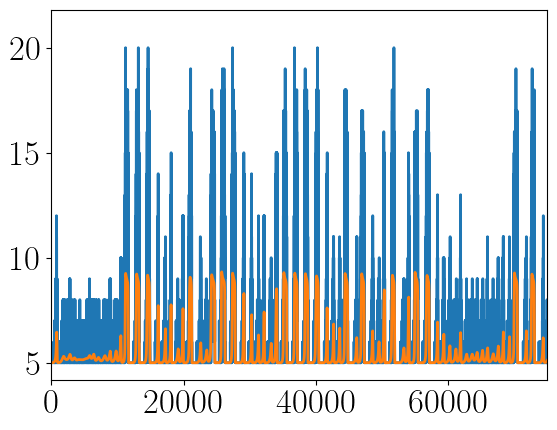

In [112]:
plt.plot(np.arange(0,25000*11,1) ,np.sum(ev,0)+5, lw = 2)
plt.plot(np.arange(0,25000*11,1) ,S_rest+5, lw = 2)
plt.xlim(0,25000*3)

In [96]:
cd C:

C:\Users\Benedetta\Desktop\Criticality in barrel cortex\Thalamus\2024 work


In [65]:
#start_rest,end_rest=2,10
restspikes =concat
#ev.T
#concatenat_spikes(binspikes[:,20:],start_rest,end_rest,nTrials, fs=25000)
#binspikes.shape,restspikes.shape
S_shape_ = np.zeros((restspikes.shape[0]))
for ch in range(restspikes.shape[1]):
    S_shape_ += restspikes[:,ch]

sizes, durations, S_shape, shape_mean, freq = avalanche_finder(S_shape_,1)

In [66]:
avinterv(S_shape_)

3

In [101]:
cd Codes/Marianietal2026-PlosCompBio/

C:\Users\Benedetta\Desktop\Criticality in barrel cortex\Thalamus\2024 work\Codes\Marianietal2026-PlosCompBio


In [67]:
from plotting_functions import *
from avalanches_functions import *

In [68]:
s = [sizes]
d = [durations]
extrinsic_par = []
h = 0

temp = []
sizes = s[h]
durations = d[h]

xm = max(sizes) if h == 0 else max(sizes)



expo = False
centredbin, pdfnorm, x, px_fit, exp, errexp, xmin = LogScript_new(sizes,1,4, xm,'default', expo)
print(xmin)

temp.append([centredbin, pdfnorm, x, px_fit, exp, errexp, xmin])
xm2 = max(durations) if h == 0 else max(durations)

centredbin, pdfnorm, x, px_fit, exp, errexp, xmin = LogScript_new(durations,1,4,xm2,'default', expo)
temp.append([centredbin, pdfnorm, x, px_fit, exp, errexp, xmin])
a, b, c, x, inter, pred, errpred, fit, errfit = scaling_new(sizes,durations,1,4,4,
                                                            'default','default','default',
                                                            'default',xm,xm2,'default','default')
print(xmin)
temp.append([sizes, durations, a, b, c, x, inter, pred, errpred, fit, errfit])
extrinsic_par.append(temp)

Calculating best minimal value for power law fit
Nbins estimated are are 34
Alpha is 1.9404395503129863
3.0
Calculating best minimal value for power law fit
Nbins estimated are are 21
Alpha is 2.2373099824259945
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Prediction from crackling noise relation: delta =  1.3156981407524926 +- 0.00654403170911098
Fit from of average size given duration points: delta =  1.703856842458898 +- 0.015410979190805814
3.0


In [130]:

import emd
aas =[]
aas2 =[]
from numpy import *
fs = 25000
#for r in range(15,22):
for s in range(binspikes.shape[0]):
    v = emd.sift.mask_sift(S_trial[s,25000*3:], mask_freqs= 35./fs, max_imfs=5, )
    low = 3
    IP, IF, IA = emd.spectra.frequency_transform(v, fs, 'nht')
    phi = IP[:,low][:]
    coef = 1
    amp = compute_density(ev_trial[s,:,25000*3:].T,50,coef)
    
    p_bins = arange(0, 2*pi, 0.1)
    a_mean = zeros(size(p_bins)-1)
    p_mean = zeros(size(p_bins)-1)
    for k in range(size(p_bins)-1):     #For each phase bin,
        pL = p_bins[k]                  #... lower phase limit,
        pR = p_bins[k+1]                #... upper phase limit.
        indices=(phi>=pL) & (phi<pR)    #Find phases falling in bin,
        a_mean[k] = mean(amp[indices])  #... compute mean amplitude,
        p_mean[k] = mean([pL, pR])      #... save center phase.
    aas.append(a_mean)

    
  

In [92]:
proc_trial = np.asarray(proc_trial)
proc_trial.shape

(28, 275000)

(50000.0, 175000.0)

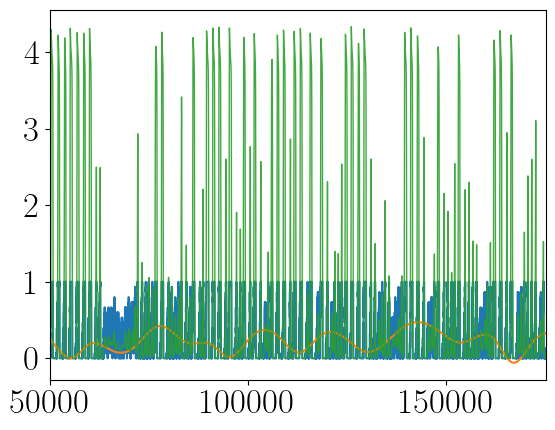

In [91]:
plt.plot(np.arange(0,25000*8,1),amp)
plt.plot(np.arange(0,25000*8,1),IA[:,low]);
plt.plot(np.arange(0,25000*8,1) ,S_trial[-1][25000*3:], lw = 1, alpha =.9)

plt.xlim(25000*2,25000*7)

C:\Users\Benedetta\AppData\Local\Temp\ipykernel_9320\4136849846.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  plot_av_statistics(ax[0], extrinsic_par[h][0][:-1], color = cm.get_cmap('Blues')(0.6),
C:\Users\Benedetta\AppData\Local\Temp\ipykernel_9320\4136849846.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  plot_av_statistics(ax[1], extrinsic_par[h][1][:-1], color = cm.get_cmap('OrRd')(0.5),
C:\Users\Benedetta\AppData\Local\Temp\ipykernel_9320\4136849846.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matpl

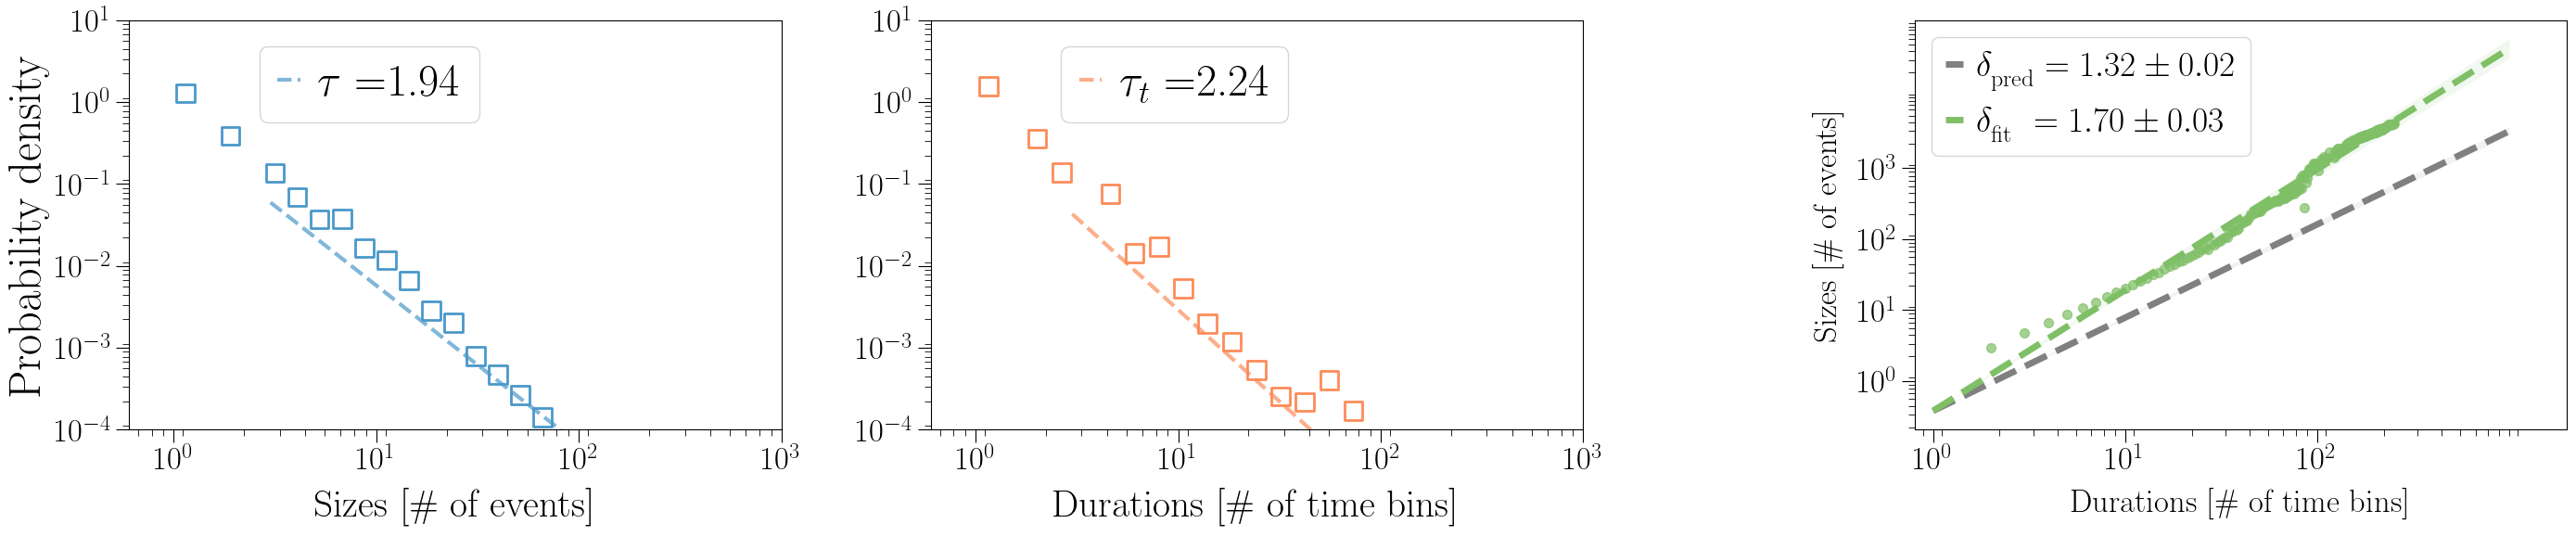

In [70]:

if expo == True:
    prediz = False
    plot_fit = False
else:
    prediz = True
    plot_fit = True
fig,ax = plt.subplots(1,4,figsize = (28,6), gridspec_kw={'width_ratios': [1,1,0.05,1]})
color = ['blue', 'red']
#datasizes = [size]
for h in range(1):
    plot_av_statistics(ax[0], extrinsic_par[h][0][:-1], color = cm.get_cmap('Blues')(0.6),
                       xmin = extrinsic_par[h][0][-1], xmax = max(sizes), label = r"$\tau$ ="+f"{round(extrinsic_par[h][0][:-1][-2],2)}",
                       marker = 's', s = 200, lw = 2, lwline = 3, alphaline = 0.7,
                       plot_fit = plot_fit,expo = expo)
   
    
    ax[0].set_xlim(0.6,1000)
    ax[0].set_ylim(0.0001,10)
    ax[0].set_xticks(np.logspace(0,3,4))

    ax[0].set_xlabel(r'Sizes [\# of events]', fontsize = 30, labelpad = 10)
    
    plot_av_statistics(ax[1], extrinsic_par[h][1][:-1], color = cm.get_cmap('OrRd')(0.5),
                   xmin = extrinsic_par[h][1][-1], xmax = max(durations), label = r"$\tau_t$ ="+ f"{round(extrinsic_par[h][1][:-1][-2],2)}",
                   marker = 's', s = 200, lw = 2, lwline = 3, alphaline = 0.7,
                   plot_fit = plot_fit, expo= expo)
    
  
    ax[1].set_xlim(0.6,500)
    ax[1].set_ylim(0.0001,10)
    ax[1].set_xticks(np.logspace(0,3,4))

    ax[1].set_xlabel(r'Durations [\# of time bins]', fontsize = 30, labelpad = 10)
    
    xmax = 1000
    plot_crackling_noise(ax[3], extrinsic_par[h][2], cpoints = 'forestgreen',
                         cpred = 'gray', cfit = cm.get_cmap('summer_r')(0.5),
                         xmin = 1, xmax = xmax, alphamarker = 0.7, s = 50, lwline = 5, prediz= prediz, fontsize=25)
  
    ax[3].legend(handletextpad=0.4, handlelength = 0.5, scatteryoffsets = [0.5],
              fontsize = 27, loc = 'upper left')


    ax[3].set_xlim(0.8,2000)
    ax[3].set_xticks([1,10,100])
    ax[3].set_yticks([1,10,100,1000])
if not expo: 
    ax[0].legend(handletextpad=0.4, handlelength = 0.5, scatteryoffsets = [0.5],
                   fontsize = 35, loc = (0.2,0.75))
    ax[1].legend(handletextpad=0.4, handlelength = 0.5, scatteryoffsets = [0.5],
                   fontsize = 35, loc = (0.2,0.75))
ax[2].remove()


ax[0].set_ylabel('Probability density', fontsize = 35)
#ax[0].yaxis.set_label_coords(-0.2,-0.17)



for j in [0,1,3]:
    locmin = matplotlib.ticker.LogLocator(base=10.0,subs=np.linspace(0,1,10),numticks=10)
    ax[j].xaxis.set_minor_locator(locmin)
    ax[j].xaxis.set_minor_formatter(matplotlib.ticker.NullFormatter())

    locmin = matplotlib.ticker.LogLocator(base=10.0,subs=np.linspace(0,1,10),numticks=10)
    ax[j].yaxis.set_minor_locator(locmin)
    ax[j].yaxis.set_minor_formatter(matplotlib.ticker.NullFormatter())

    ax[j].tick_params(length = 5, which = 'minor')
    ax[j].tick_params(length = 10)


fig.tight_layout(pad = .6,h_pad = 2)
plt.subplots_adjust(hspace = 0.4, wspace = 0.3)
plt.savefig(path_figures + '/' + 'model_avalanches_jpg', dpi = 300, bbox_inches ='tight')

plt.show()

In [96]:
S_trial = np.asarray(S_trial)

In [134]:
path_figures

'C:/Users/Benedetta/Desktop/Criticality in barrel cortex/Thalamus/Paper figures'

In [131]:
plt.rcParams['font.size']

25.0

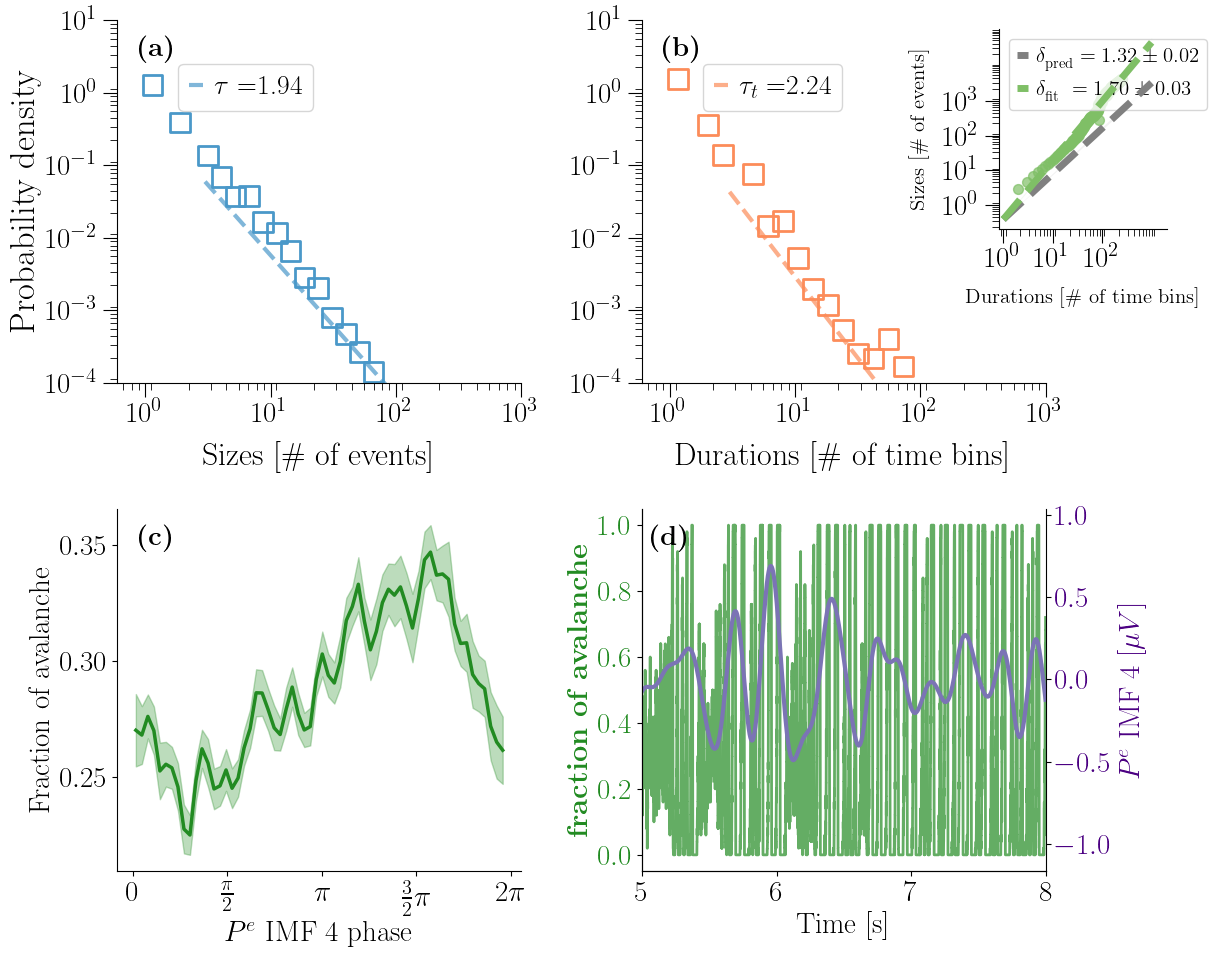

In [174]:
# import emd
sample_rate = 25000

plt.rcParams['font.size'] = 21
plt.rcParams['axes.spines.top']= False
plt.rcParams['axes.spines.right']= False

if expo == True:
    prediz = False
    plot_fit = False
else:
    prediz = True
    plot_fit = True
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax = plt.subplots(2,2,figsize =(12,10))
left, bottom, width, height  = [0.85, 0.75, 0.14, 0.2]

ax3 = fig.add_axes([left, bottom, width, height])


color = ['blue', 'red']
#datasizes = [size]
for h in range(1):
    plot_av_statistics(ax[0,0], extrinsic_par[h][0][:-1], color = cm.get_cmap('Blues')(0.6),
                       xmin = extrinsic_par[h][0][-1], xmax = max(sizes), label = r"$\tau$ ="+f"{round(extrinsic_par[h][0][:-1][-2],2)}",
                       marker = 's', s = 200, lw = 2, lwline = 3, alphaline = 0.7,
                       plot_fit = plot_fit,expo = expo)
   
    
    ax[0,0].set_xlim(0.6,1000)
    ax[0,0].set_ylim(0.0001,10)
    ax[0,0].set_xticks(np.logspace(0,3,4))

    ax[0,0].set_xlabel(r'Sizes [\# of events]', fontsize = 23, labelpad = 10)
    
    plot_av_statistics(ax[0,1], extrinsic_par[h][1][:-1], color = cm.get_cmap('OrRd')(0.5),
                   xmin = extrinsic_par[h][1][-1], xmax = max(durations), label = r"$\tau_t$ ="+ f"{round(extrinsic_par[h][1][:-1][-2],2)}",
                   marker = 's', s = 200, lw = 2, lwline = 3, alphaline = 0.7,
                   plot_fit = plot_fit, expo= expo)
    
  
    ax[0,1].set_xlim(0.6,500)
    ax[0,1].set_ylim(0.0001,10)
    ax[0,1].set_xticks(np.logspace(0,3,4))

    ax[0,1].set_xlabel(r'Durations [\# of time bins]', fontsize = 23, labelpad = 10)
    
    xmax = 1000

    
    plot_crackling_noise(ax3, extrinsic_par[h][2], cpoints = 'forestgreen',
                         cpred = 'gray', cfit = cm.get_cmap('summer_r')(0.5),
                         xmin = 1, xmax = xmax, alphamarker = 0.7, s = 50, lwline = 5, prediz= prediz)
  
    ax3.legend(handletextpad=0.4, handlelength = 0.5, scatteryoffsets = [0.5],
              fontsize = 15, loc = 'upper left')

    ax3.set_xlim(0.8,2000)
    ax3.set_xticks([1,10,100])
    ax3.set_yticks([1,10,100,1000])
    
if not expo: 
    ax[0,0].legend(handletextpad=0.4, handlelength = 0.5, scatteryoffsets = [0.5],
                   fontsize = 20, loc = (0.15,0.75))
    ax[0,1].legend(handletextpad=0.4, handlelength = 0.5, scatteryoffsets = [0.5],
                   fontsize = 20, loc = (0.15,0.75))

ax[0,0].set_ylabel('Probability density', fontsize = 25)
#ax[0].yaxis.set_label_coords(-0.2,-0.17)



for ax_ in [ax[0,0],ax[0,1],ax3]:
    locmin = matplotlib.ticker.LogLocator(base=10.0,subs=np.linspace(0,1,10),numticks=10)
    ax_.xaxis.set_minor_locator(locmin)
    ax_.xaxis.set_minor_formatter(matplotlib.ticker.NullFormatter())

    locmin = matplotlib.ticker.LogLocator(base=10.0,subs=np.linspace(0,1,10),numticks=10)
    ax_.yaxis.set_minor_locator(locmin)
    ax_.yaxis.set_minor_formatter(matplotlib.ticker.NullFormatter())

    ax_.tick_params(length = 5, which = 'minor')
    ax_.tick_params(length = 10)

#from scipy import ndimage
mean_interspike_time = 3
coef = 5

aasmean = np.roll(np.mean(np.asarray(aas),0),35)
aas2 = np.roll(np.asarray(aas),35)

ax[1,0].fill_between(p_mean,aasmean - np.std(aas2,0)/np.sqrt(len(aas2)),aasmean+ np.std(aas2,0)/np.sqrt(len(aas)),color='forestgreen', alpha =.3)
ax[1,0].plot(p_mean, aasmean, color ='forestgreen', lw = 2.5)
ax[1,0].set_xlabel(r'$P^{e}$ IMF 4 phase')
ax[1,0].set_ylabel('Fraction of avalanche');


plt.rcParams['axes.spines.right']= True

t = np.arange(0,25000*8,1)/25000 + 2
trial_ = 5



v = emd.sift.mask_sift(S_trial[trial_,25000*3:], mask_freqs= 35./fs, max_imfs=5, )
amp = compute_density(ev_trial[trial_,:,25000*3:].T, 50,1 )
ax[1,1].plot(t,amp, color = 'forestgreen', lw = 2,alpha = .7)

ax[1,1].set_ylabel(r'\textbf{fraction of avalanche} ', color='forestgreen',)  # we already handled the x-label with ax1

ax[1,1].set_xlabel('Time [s]')
ax[1,1].tick_params(axis='y', labelcolor='forestgreen',)

ax2 = ax[1,1].twinx() # instantiate a second Axes that shares the same x-axis
ax[1,1].set_xlim(5,8)
color = 'indigo'

_,_,IA_low=  emd.spectra.frequency_transform((v[:,3] + v[:,4]), sample_rate, 'nht')
ax2.tick_params(axis='y', labelcolor=color)
ax2.plot(t, (v[:,3] + v[:,4]), color = cm.get_cmap('Purples')(0.65), lw = 3,alpha = 1)
ax2.set_ylabel(r'$P^{e}$ IMF 4 [$\mu V$]', color =color)



ax[1,0].set_xticks([0,np.pi/2,np.pi,3/2*np.pi, 2*np.pi])
ax[1,0].set_xticklabels(["0",r"$\frac{\pi}{2}$",r"$\pi$",r"$\frac{3}{2}\pi$", r"$2\pi$"])


ax[1,0].annotate('\\textbf{(c)}', size = 20,
                 xy=(1, 1), xycoords='axes fraction',
                 xytext=(0.05, 0.9), textcoords='axes fraction')
ax[1,1].annotate('\\textbf{(d)}', size = 20,
                 xy=(1, 1), xycoords='axes fraction',
                 xytext=(0.02,0.9), textcoords='axes fraction')

ax[0,0].annotate('\\textbf{(a)}', size = 20,
                 xy=(1, 1), xycoords='axes fraction',
                 xytext=(0.05, 0.9), textcoords='axes fraction')
ax[0,1].annotate('\\textbf{(b)}', size = 20,
                 xy=(1, 1), xycoords='axes fraction',
                 xytext=(0.05,0.9), textcoords='axes fraction')

plt.tight_layout()
plt.savefig(path_figures+"/Figura_5a_model.jpg", dpi = 300, bbox_inches = 'tight')
plt.savefig(path_figures+"/Figura_5a_model.tif", dpi = 300, bbox_inches = 'tight')


In [165]:
len(p_mean), len(p_bins), len(phase_bins2)

(62, 63, 23)

In [140]:
S_trial.shape

(28, 275000)

## Figura 5 b

In [146]:

path2 = 'C:/Users/Benedetta/Desktop/Criticality in barrel cortex/Thalamus/2024 work'

In [141]:
import emd
from mpl_toolkits.axes_grid1 import make_axes_locatable
final_rest = []


T = 1000*2.5
sample_rate = 25000
taue = 5
dt = 0.04
N = int(T/dt)
times = np.arange(0,T,0.04)
times = times*1e-3

for trial in range(fir.shape[0]):
    ii = 35

    x = S_trial[trial][25000*6:]
    imf2 = emd.sift.mask_sift(x, mask_freqs =ii/sample_rate)
    IP, IF, IA = emd.spectra.frequency_transform(imf2, sample_rate, 'nht')
    freq_range = (0, 45, 64)

    hht_f, spec = emd.spectra.hilberthuang(IF, IA, freq_range, scaling='density', sum_imfs=False)
    #hht_f, spec_nonlinear = emd.spectra.hilberthuang(IF_nonlinear, IA_nonlinear, freq_range, scaling='density', sum_imfs=False)

    final_rest.append(spec)

final_rest = np.asarray(final_rest)
final_rest.shape

(28, 64, 8)

In [142]:
import emd
from mpl_toolkits.axes_grid1 import make_axes_locatable
final = []


for trial in range(fir.shape[0]):


    x = S_trial[trial][25000:25000*2]
    imf2 = emd.sift.mask_sift(x, mask_freqs =ii/sample_rate)
    IP, IF, IA = emd.spectra.frequency_transform(imf2, sample_rate, 'nht')
    freq_range = (0, 45, 64)

    hht_f, spec = emd.spectra.hilberthuang(IF, IA, freq_range, scaling='density', sum_imfs=False)
    #hht_f, spec_nonlinear = emd.spectra.hilberthuang(IF_nonlinear, IA_nonlinear, freq_range, scaling='density', sum_imfs=False)

    final.append(spec)

final = np.asarray(final)
final.shape

(28, 64, 6)

In [143]:

aa = []
aa1 = []
#tr, ch = 0,17
#for ch in [15,17,18,19,20,21]:
for tr in range(28):
    x = S_trial[tr,25000*3:]
    t = np.arange(0,len(x),1)/sample_rate
    num = int(len(x)/sample_rate)
    ii = 35
    imf = emd.sift.mask_sift(x, max_imfs=9, mask_freqs= ii/sample_rate, ret_mask_freq=True)
    IP, IF, IA = emd.spectra.frequency_transform(imf[0], sample_rate, 'nht')
    ### qua l'ho fatto solo per un canale andrebbe fatto per pù canali e trails!!
    ref1 = 3
    ref2 = 1
    #ref3 = 2

    #IP, IF, IA = emd.spectra.frequency_transform(imf[0], sample_rate, 'nht')
    ia_by_phase2, ia_by_phase_var2, phase_bins2 = emd.cycles.bin_by_phase(IP[:,ref1], IA[:, ref2], variance_metric ='std')
    phase_bins2 = phase_bins2[~np.isnan(ia_by_phase2)]
    ia_by_phase_var2 = ia_by_phase_var2[~np.isnan(ia_by_phase2)]
    ia_by_phase2 = ia_by_phase2[~np.isnan(ia_by_phase2)]
    aa.append((ia_by_phase2-np.mean(ia_by_phase2))/np.std(ia_by_phase2))
    aa1.append(ia_by_phase2)

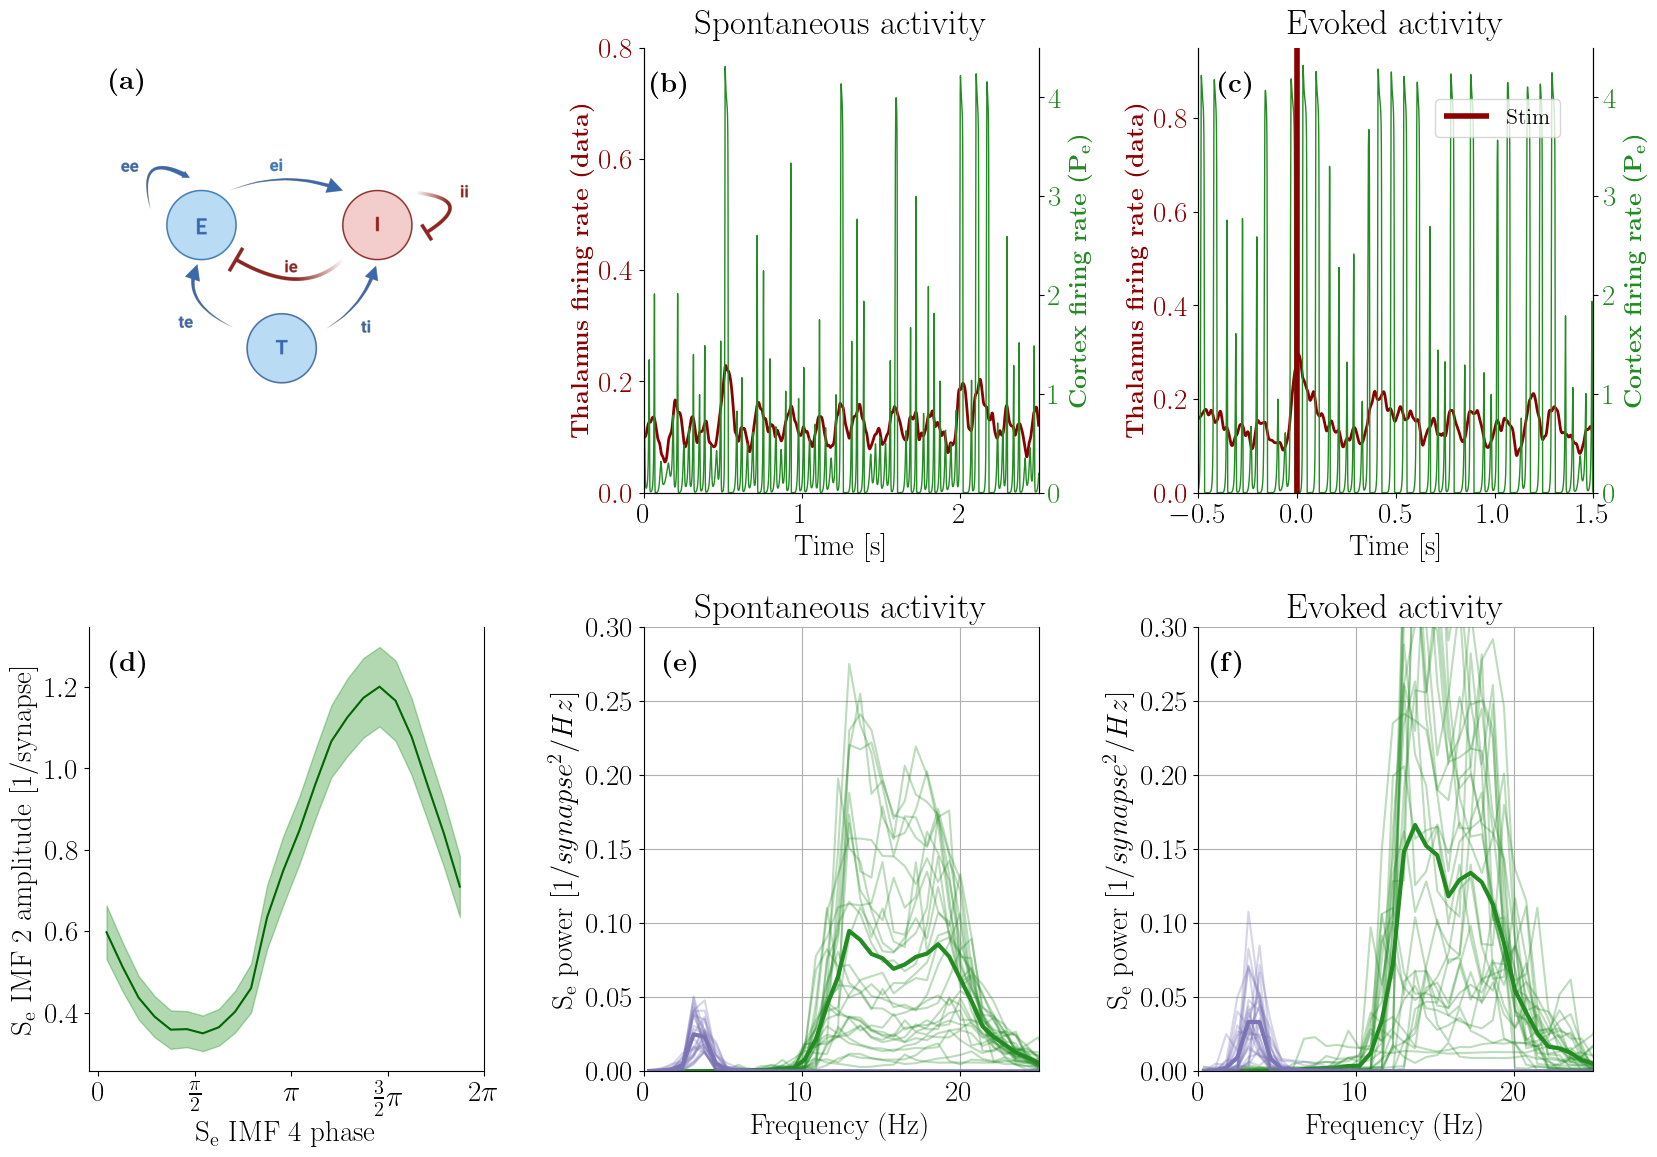

In [170]:
import emd
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib import cm
import warnings
warnings.filterwarnings('ignore')

trial = 0




fig, ax = plt.subplots(2,3,figsize =(17,12))
ax1 = ax[0,0]

#f = plt.figure(figsize = (10,10))
#ax = fig.add_subplot(1,3,1)
ax1.spines['top'].set_visible(False)
ax1.spines['bottom'].set_visible(False)

ax1.spines['left'].set_visible(False)

ax1.spines['right'].set_visible(False)
ax1.set_xlim(0,3000)
ax1.set_ylim(2500,200)
ax1.set_xticks([])
ax1.set_yticks([])


ax1.imshow(plt.imread(os.path.join(path2,'Untitled (1).png')), origin ='upper',resample = 0.1,)
#fig =plt.figure()
# instantiate a second axes that shares the same x-axis
#color=colors[1]
T = 1000*3
times = np.arange(0,T,0.04)
times = times*1e-3
ax2 =ax[0,1]



S_rest = S_trial[trial, 25000*3:25000*6]
S_stim = S_trial[trial, :25000*3]

proc_rest = proc_trial[trial, 25000*3: 25000*6]
proc_stim = proc_trial[trial, :25000*3]

ax2.set_title('Spontaneous activity', pad = 10)

ax2.set_ylabel(r'\textbf{Thalamus firing rate (data)}',fontsize = 18,color = 'darkred')  # we already handled the x-label with ax1
ax2.plot(times,proc_rest, color='darkred',lw = 2, alpha = 1)
ax2.tick_params(axis='y', labelcolor='darkred')

ax2.set_xlabel('Time [s]');

ax1 = ax2.twinx()  
ax1.set_xlabel('')
ax1.set_ylabel(r'\textbf{Cortex firing rate (\textbf{P\textsubscript{e}})}',fontsize = 18, color='forestgreen')
ax1.plot(times, S_rest, color='forestgreen', lw = 1)
ax1.tick_params(axis='y', labelcolor='forestgreen')
plt.xlim(0,2.5)


ax2.set_ylim(0.,.8)
ax1.set_ylim(0.,4.5)

ax2 = ax[0,2]
ax2.set_title('Evoked activity', pad = 10)
T = 1000*3
times = np.arange(0,T,0.04)
times = times*1e-3-1
ax2.set_ylabel(r'\textbf{Thalamus firing rate (data)}',fontsize = 18,color = 'darkred')  # we already handled the x-label with ax1
ax2.plot(times,proc_stim, color='darkred',lw = 2, alpha = 1)
ax2.tick_params(axis='y', labelcolor='darkred')

ax2.set_xlabel('Time [s]');
ax1 = ax2.twinx()  
ax1.set_xlabel('')
ax1.set_ylabel(r'\textbf{Cortex firing rate (\textbf{P\textsubscript{e}})}',fontsize = 18, color='forestgreen')
ax1.plot(times, S_stim, color='forestgreen', lw = 1)
ax1.tick_params(axis='y', labelcolor='forestgreen')

ax1.vlines(0,0,5,color = 'darkred', lw = 4, label ='Stim')
plt.legend(loc = (0.6,0.8), fontsize = 16)
plt.xlim(-.5,1.5)
ax2.set_ylim(0.,.95)
ax1.set_ylim(0.,4.5)








from scipy import ndimage


aasmean = np.roll(np.mean(np.asarray(aa1),0),10)
aas2 = np.roll(aa1,10)

ax[1,0].fill_between(phase_bins2,aasmean - np.std(aas2,0)/np.sqrt(len(aas2)),aasmean+ np.std(aas2,0)/np.sqrt(len(aas)),color='green', alpha =.3)
ax[1,0].plot(phase_bins2, aasmean, color ='darkgreen')



ax[1,0].set_xlabel(r'S\textsubscript{e} IMF 4 phase')
ax[1,0].set_ylabel(r'S\textsubscript{e} IMF 2 amplitude [1/synapse]');



ax[1,0].set_xticks([0,np.pi/2,np.pi,3/2*np.pi, 2*np.pi])
ax[1,0].set_xticklabels(["0",r"$\frac{\pi}{2}$",r"$\pi$",r"$\frac{3}{2}\pi$", r"$2\pi$"])








ax22 = ax[1,2]
ax22.plot(hht_f,final[:,:,1].T, color = 'forestgreen', alpha = 0.3);
ax22.plot(hht_f,np.mean(final[:,:,1],0), color = 'forestgreen', lw = 3);
ax22.plot(hht_f,final[:,:,3].T, color = cm.get_cmap('Purples')(0.65), alpha = 0.3)
#plt.title('Spontaneous activity')
ax22.plot(hht_f,np.mean(final[:,:,3],0), color = cm.get_cmap('Purples')(0.65), lw = 3);

ax02 = ax[1,1]
ax02.plot(hht_f,final_rest[:,:,1].T, color = 'forestgreen', alpha = 0.3);
ax02.plot(hht_f,np.mean(final_rest[:,:,1],0), color = 'forestgreen', lw=3);


ax02.plot(hht_f,final_rest[:,:,3].T, color = cm.get_cmap('Purples')(0.65), alpha = 0.3);
ax02.plot(hht_f,np.mean(final_rest[:,:,3],0), color = cm.get_cmap('Purples')(0.65), lw = 3);


ax02.grid(True)
ax22.grid(True)
ax02.set_title('Spontaneous activity')
ax22.set_title('Evoked activity')

ax02.set_xlim(0, 25)
ax22.set_xlim(0, 25)
ax02.set_ylim(0, 0.3)
ax22.set_ylim(0, 0.3)

ax02.set_xlabel('Frequency (Hz)');
ax22.set_xlabel('Frequency (Hz)');
ax02.set_ylabel(r"S\textsubscript{e} power $[1/synapse^2/Hz]$")
ax22.set_ylabel(r"S\textsubscript{e} power $[1/synapse^2/Hz]$")


ax[0,0].annotate('\\textbf{(a)}', size = 20,
                 xy=(1, 1), xycoords='axes fraction',
                 xytext=(0.05, 1.1), textcoords='axes fraction')
ax[0,1].annotate('\\textbf{(b)}', size = 20,
                 xy=(1, 1), xycoords='axes fraction',
                 xytext=(0.015,0.9), textcoords='axes fraction')
ax[0,2].annotate('\\textbf{(c)}', size = 20,
                 xy=(1, 1), xycoords='axes fraction',
                 xytext=(0.05,0.9), textcoords='axes fraction')

ax[1,0].annotate('\\textbf{(d)}', size = 20,
                 xy=(1, 1), xycoords='axes fraction',
                 xytext=(0.05, 0.9), textcoords='axes fraction')
ax[1,1].annotate('\\textbf{(e)}', size = 20,
                 xy=(1, 1), xycoords='axes fraction',
                 xytext=(0.05,0.9), textcoords='axes fraction')
ax[1,2].annotate('\\textbf{(f)}', size = 20,
                 xy=(1, 1), xycoords='axes fraction',
                 xytext=(0.03,0.9), textcoords='axes fraction')


plt.tight_layout()
#plt.savefig(os.path.join(path_figures,"Figura_5_final.jpg"), bbox_inches = 'tight' , dpi = 300)
plt.savefig(path_figures+"/Figura_5b_model.jpg", dpi = 300, bbox_inches = 'tight')
plt.savefig(path_figures+"/Figura_5b_model.tif", dpi = 300, bbox_inches = 'tight')


In [157]:
plt.rcParams['font.size'] =23